# Ejercicio1 - Busqueda de Alojamiento en Airbnb (Jupyter).

Supongamos que somos un agente de [Airbnb](http://www.airbnb.com) localizado en Lisboa, y tenemos que atender peticiones de varios clientes. Tenemos un archivo llamado `airbnb.csv` (en la carpeta data) donde tenemos información de todos los alojamientos de Airbnb en Lisboa.

In [27]:
import pandas as pd
df_airbnb = pd.read_csv("./data/airbnb.csv")

In [28]:
df_airbnb.head()

,room_id,host_id,room_type,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,price
0,6499,14455,Entire home/apt,Belém,8,5.0,2,1.0,57.0
1,17031,66015,Entire home/apt,Alvalade,0,0.0,2,1.0,46.0
2,25659,107347,Entire home/apt,Santa Maria Maior,63,5.0,3,1.0,69.0
3,29248,125768,Entire home/apt,Santa Maria Maior,225,4.5,4,1.0,58.0
4,29396,126415,Entire home/apt,Santa Maria Maior,132,5.0,4,1.0,67.0


En concreto el dataset tiene las siguientes variables:
- room_id: el identificador de la propiedad
- host_id: el identificador del dueño de la propiedad
- room_type: tipo de propiedad (vivienda completa/(habitacion para compartir/habitación privada)
- neighborhood: el barrio de Lisboa
- reviews: El numero de opiniones
- overall_satisfaction: Puntuacion media del apartamento
- accommodates: El numero de personas que se pueden alojar en la propiedad
- bedrooms: El número de habitaciones
- price: El precio (en euros) por noche

## Ejercicios

### 1. Realizar Análisis Exploratorio de los datos

Sobre este apartado deberá explorar los datos como se vio en clase .. aplicar métodos shape, columns, etc

In [29]:
# 1. Obtener la dimensión del DataFrame (filas, columnas)
print(df_airbnb.shape)

(13232, 9)


In [30]:
# 2. Listar los nombres de todas las columnas
print(df_airbnb.columns)

Index(['room_id', 'host_id', 'room_type', 'neighborhood', 'reviews',
       'overall_satisfaction', 'accommodates', 'bedrooms', 'price'],
      dtype='object')


In [31]:
# 3. Obtener un resumen de la estructura del DataFrame
df_airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13232 entries, 0 to 13231
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   room_id               13232 non-null  int64  
 1   host_id               13232 non-null  int64  
 2   room_type             13232 non-null  object 
 3   neighborhood          13232 non-null  object 
 4   reviews               13232 non-null  int64  
 5   overall_satisfaction  13222 non-null  float64
 6   accommodates          13232 non-null  int64  
 7   bedrooms              13232 non-null  float64
 8   price                 13232 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 930.5+ KB


In [32]:
# 4. Muestra estadísticas descriptivas de las columnas numéricas
df_airbnb.describe()

,room_id,host_id,reviews,overall_satisfaction,accommodates,bedrooms,price
count,1.323200e+04,1.323200e+04,13232.000000,13222.000000,13232.000000,13232.000000,13232.000000
mean,1.055081e+07,3.616444e+07,29.130063,3.284677,3.917775,1.549501,86.592352
std,6.069884e+06,3.706975e+07,42.802762,2.123236,2.293757,1.062821,135.208926
min,6.499000e+03,1.445500e+04,0.000000,0.000000,1.000000,0.000000,10.000000
25%,5.054848e+06,6.197930e+06,2.000000,0.000000,2.000000,1.000000,45.000000
50%,1.166226e+07,2.207571e+07,11.000000,4.500000,4.000000,1.000000,64.000000
75%,1.609631e+07,5.546697e+07,39.000000,5.000000,5.000000,2.000000,93.000000
max,1.940072e+07,1.359156e+08,438.000000,5.000000,16.000000,10.000000,7496.000000


In [33]:
# 5. Muestra cuántos valores únicos hay en cada columna
df_airbnb.nunique()

room_id                 13232
host_id                  6418
room_type                   3
neighborhood               24
reviews                   267
overall_satisfaction        9
accommodates               16
bedrooms                   11
price                     282
dtype: int64

In [34]:
# 6. Muestra el tipo de dato de cada columna
df_airbnb.dtypes

room_id                   int64
host_id                   int64
room_type                object
neighborhood             object
reviews                   int64
overall_satisfaction    float64
accommodates              int64
bedrooms                float64
price                   float64
dtype: object

In [35]:
# 7.
# Muestra cuántos alojamientos hay de cada tipo
print ("¿Cuantos alojamientos de cada tipo hay (Room Type)?")
print (50*"-")
print(df_airbnb['room_type'].value_counts())

print ("\n") # Se agrega un salto de línea para separar visualmente

# Muestra cuántos alojamientos hay por barrio
print ("¿Cuantos alojamientos hay por barrio?")
print (50*"-")
print(df_airbnb['neighborhood'].value_counts())


¿Cuantos alojamientos de cada tipo hay (Room Type)?
--------------------------------------------------
room_type
Entire home/apt    9764
Private room       3297
Shared room         171
Name: count, dtype: int64


¿Cuantos alojamientos hay por barrio?
--------------------------------------------------
neighborhood
Santa Maria Maior          2798
Misericórdia               2402
Arroios                    1664
Santo António              1105
São Vicente                1041
Estrela                     803
Avenidas Novas              566
Penha de França             407
Campo de Ourique            319
Areeiro                     280
Belém                       254
Alvalade                    253
Parque das Nações           250
Alcântara                   213
São Domingos de Benfica     138
Lumiar                      124
Campolide                   123
Ajuda                       108
Olivais                     108
Beato                        84
Benfica                      71
Marvila      

In [36]:
# 8. Cuenta el número total de filas duplicadas
df_airbnb.duplicated().sum()

np.int64(0)

In [37]:
# 9.
# Muestra el valor mínimo, el valor máximo y el precio promedio
print(f"Precio Mínimo: {df_airbnb['price'].min()}€")
print(f"Precio Máximo: {df_airbnb['price'].max()}€")
print(f"Precio Promedio: {df_airbnb['price'].mean():.2f}€")

# Muestra el precio en el percentil 95 (para ignorar los valores extremos más caros)
print(f"El 95% de los alojamientos cuesta menos de: {df_airbnb['price'].quantile(0.95)}€")

Precio Mínimo: 10.0€
Precio Máximo: 7496.0€
Precio Promedio: 86.59€
El 95% de los alojamientos cuesta menos de: 191.0€


### 2. Realizar Filtrados a Datos

- Realizar filtrados, según sea el caso. 


Nota: 
Para obtener el top de un conjunto de datos debemos aplicar un head(n) además de ordenar los datos

#### Caso 1.

Alicia va a ir a Lisboa durante una semana con su marido y sus 2 hijos. Están buscando un apartamento con habitaciones separadas para los padres y los hijos. No les importa donde alojarse o el precio, simplemente quieren tener una experiencia agradable. Esto significa que solo aceptan lugares con más de 10 críticas con una puntuación mayor de 4. Cuando seleccionemos habitaciones para Alicia, tenemos que asegurarnos de ordenar las habitaciones de mejor a peor puntuación. Para aquellas habitaciones que tienen la misma puntuación, debemos mostrar antes aquellas con más críticas. Debemos darle 3 alternativas.

In [38]:
# 1. FILTRAR: Lugares con más de 10 críticas y puntuación mayor a 4
df_filtrado = df_airbnb[
    (df_airbnb['reviews'] > 10) & 
    (df_airbnb['overall_satisfaction'] > 4)
]

# 2. ORDENAR: Primero por puntuación (descendente), luego por críticas (descendente)
df_alicia = df_filtrado.sort_values(
    by=['overall_satisfaction', 'reviews'], 
    ascending=[False, False]               
)

# 3. SELECCIONAR: El top 3 de los alojamientos ordenados
alternativas_alicia = df_alicia.head(3)

# Mostrar el resultado
print(f"Alojamientos que cumplen los filtros iniciales: {df_filtrado.shape[0]}")
print("\nLas 3 mejores alternativas para Alicia son:")
alternativas_alicia

Alojamientos que cumplen los filtros iniciales: 6121

Las 3 mejores alternativas para Alicia son:


,room_id,host_id,room_type,neighborhood,reviews,overall_satisfaction,accommodates,bedrooms,price
120,176153,842219,Entire home/apt,Misericórdia,438,5.0,4,2.0,102.0
931,1085634,5968047,Entire home/apt,Misericórdia,379,5.0,2,1.0,52.0
212,299321,199452,Entire home/apt,Santo António,337,5.0,2,1.0,87.0


#### Caso 2

Roberto es un casero que tiene una casa en Airbnb. De vez en cuando nos llama preguntando sobre cuales son las críticas de su alojamiento. Hoy está particularmente enfadado, ya que su hermana Clara ha puesto una casa en Airbnb y Roberto quiere asegurarse de que su casa tiene más críticas que las de Clara. Tenemos que crear un dataframe con las propiedades de ambos. Las id de las casas de Roberto y Clara son 97503 y 90387  respectivamente. Finalmente guardamos este dataframe como excel llamado "roberto.xls

In [39]:
# IDs de Roberto y Clara
ids_a_buscar = [97503, 90387]

# 1. Filtrar el DataFrame
df_roberto_clara = df_airbnb[df_airbnb['room_id'].isin(ids_a_buscar)]

# Opcional: Mostrar quién tiene más críticas (para tranquilizar a Roberto)
roberto_reviews = df_roberto_clara[df_roberto_clara['room_id'] == 97503]['reviews'].iloc[0]
clara_reviews = df_roberto_clara[df_roberto_clara['room_id'] == 90387]['reviews'].iloc[0]

if roberto_reviews > clara_reviews:
    print("Roberto tiene más críticas que Clara.")
else:
    print("Parece que Clara tiene más críticas.")


print("\nDataFrame con las propiedades de Roberto y Clara:")
print(df_roberto_clara)


# 2. Exportar a Excel
df_roberto_clara.to_excel("roberto.xlsx", index=False)
print("\nEl DataFrame se ha guardado exitosamente como 'roberto.xlsx'")

Parece que Clara tiene más críticas.

DataFrame con las propiedades de Roberto y Clara:
    room_id  host_id     room_type   neighborhood  reviews  \
41    90387   490050  Private room  Santo António      204   
48    97503   515924  Private room  Santo António       39   

    overall_satisfaction  accommodates  bedrooms  price  
41                   5.0             2       1.0   46.0  
48                   4.0             2       1.0   26.0  

El DataFrame se ha guardado exitosamente como 'roberto.xlsx'



#### Caso 3

Diana va a Lisboa a pasar 3 noches y quiere conocer a gente nueva. Tiene un presupuesto de 50€ para su alojamiento. Debemos buscarle las 10 propiedades más baratas, dandole preferencia a aquellas que sean habitaciones compartidas *(room_type == Shared room)*, y para aquellas viviendas compartidas debemos elegir aquellas con mejor puntuación.

In [40]:
# 1. FILTRAR: Solo propiedades con precio <= 50
df_diana_presupuesto = df_airbnb[df_airbnb['price'] <= 50].copy()

# 2. CREAR COLUMNA TEMPORAL para priorizar 'Shared room' (True)
df_diana_presupuesto['is_shared'] = df_diana_presupuesto['room_type'] == 'Shared room'

# 3. ORDENAR:
#    a) is_shared (False): Para poner las compartidas primero.
#    b) overall_satisfaction (False): Para la mejor puntuación.
#    c) price (True): Para el precio más bajo.
df_ordenado_diana = df_diana_presupuesto.sort_values(
    by=['is_shared', 'overall_satisfaction', 'price'],
    ascending=[False, False, True]
)

# 4. SELECCIONAR: El Top 10
top_10_diana = df_ordenado_diana.head(10)

print(f"Alojamientos dentro del presupuesto (<= 50€): {df_diana_presupuesto.shape[0]}")
print("\nEl Top 10 de alternativas para Diana es (ordenado por: Compartida > Puntuación > Precio):")

# Mostrar las columnas clave del resultado final
top_10_diana[['room_id', 'room_type', 'neighborhood', 'overall_satisfaction', 'price', 'reviews']]

Alojamientos dentro del presupuesto (<= 50€): 4139

El Top 10 de alternativas para Diana es (ordenado por: Compartida > Puntuación > Precio):


,room_id,room_type,neighborhood,overall_satisfaction,price,reviews
9065,14933182,Shared room,Santo António,5.0,11.0,5
6056,10397682,Shared room,Misericórdia,5.0,13.0,15
7060,12299998,Shared room,Arroios,5.0,13.0,49
7066,12305540,Shared room,Arroios,5.0,13.0,40
8918,14719962,Shared room,Avenidas Novas,5.0,13.0,4
7034,12268067,Shared room,Arroios,5.0,16.0,96
9964,16150682,Shared room,Avenidas Novas,5.0,16.0,4
10723,17096560,Shared room,Areeiro,5.0,16.0,5
6459,11427995,Shared room,Misericórdia,5.0,18.0,21
11058,17497074,Shared room,Arroios,5.0,18.0,7


### 3. Realizar Agrupamientos de Datos


- Según su criterio, aplicar 2 tipos de agrupamientos a los datos brindados. 
- **Opcional**, averiguar como realizar el gráfico de los 2 agrupamientos de los datos realizados. Se podría emplear librerias como mathplot y searbon ... ayudarse de chatgtp, etc


In [41]:
# 1. Agrupar por 'room_type' y calcular la media de satisfacción y precio
grupo_tipo_habitacion = df_airbnb.groupby('room_type').agg({
    'overall_satisfaction': 'mean',
    'price': 'mean',
    'room_id': 'count' # Contamos el número de alojamientos por tipo
}).rename(columns={'room_id': 'Total_Alojamientos'})

print("Resumen por Tipo de Habitación:")
grupo_tipo_habitacion.sort_values(by='overall_satisfaction', ascending=False)

Resumen por Tipo de Habitación:


,overall_satisfaction,price,Total_Alojamientos
room_type,,,
Entire home/apt,3.529526,101.338181,9764
Private room,2.604034,45.629967,3297
Shared room,2.441520,34.397661,171


In [42]:
# 2. Agrupar por 'neighborhood' y calcular la media de precio, satisfacción y el conteo de alojamientos
grupo_barrio = df_airbnb.groupby('neighborhood').agg({
    'price': 'mean',
    'overall_satisfaction': 'mean',
    'room_id': 'count'
}).rename(columns={'room_id': 'Total_Alojamientos'})

print("\nTop 5 Barrios con Precios Promedio más Altos:")
grupo_barrio.sort_values(by='price', ascending=False).head()


Top 5 Barrios con Precios Promedio más Altos:


,price,overall_satisfaction,Total_Alojamientos
neighborhood,,,
Benfica,270.816901,2.218310,71
Carnide,229.829787,1.180851,47
São Domingos de Benfica,203.152174,1.884058,138
Parque das Nações,110.456000,2.534000,250
Campo de Ourique,102.275862,2.996865,319


/tmp/ipykernel_20112/4063918698.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


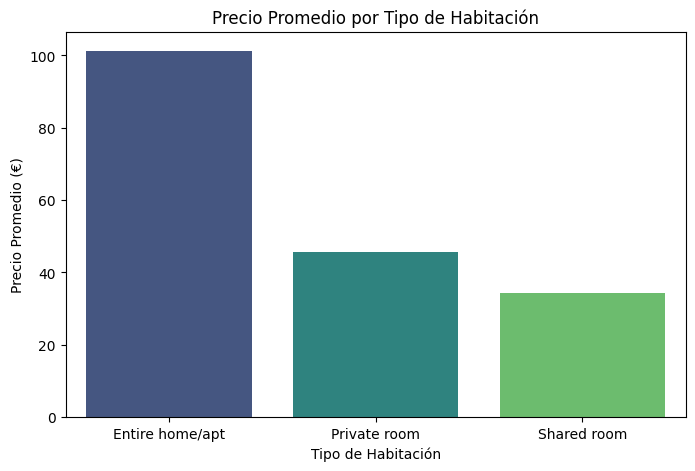

In [43]:
# Gráfico 1: Precio Promedio por Tipo de Habitación
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(
    x=grupo_tipo_habitacion.index, 
    y='price', 
    data=grupo_tipo_habitacion, 
    palette='viridis'
)
plt.title('Precio Promedio por Tipo de Habitación')
plt.ylabel('Precio Promedio (€)')
plt.xlabel('Tipo de Habitación')
plt.show()

/tmp/ipykernel_20112/398489618.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


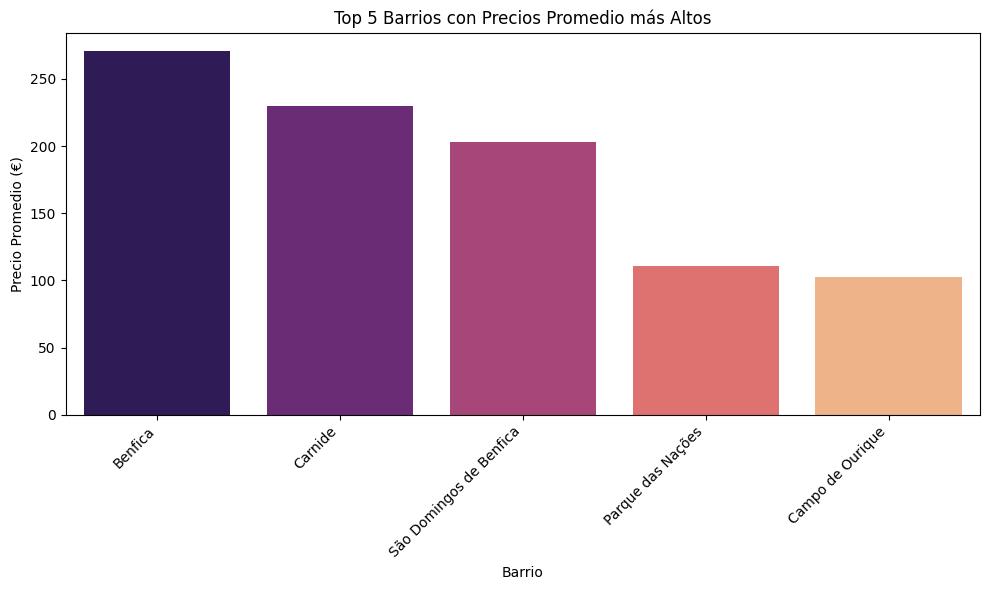

In [46]:
# Gráfico 2: Top 5 Barrios por Precio Promedio
top_5_barrios = grupo_barrio.sort_values(by='price', ascending=False).head(5)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=top_5_barrios.index, 
    y='price', 
    data=top_5_barrios, 
    palette='magma'
)
plt.title('Top 5 Barrios con Precios Promedio más Altos')
plt.ylabel('Precio Promedio (€)')
plt.xlabel('Barrio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()